# 실습 04. 경사하강법

## 데이터
- `data/boston_housing_train.csv`
- 입력 feature: `RM` 평균 방 개수
- target: `MEDV` 주택 가격 중앙값

## 불러온 데이터와 컬럼 정보

### Boston Housing 데이터
- 파일 경로: `data/boston_housing_train.csv`
- 데이터 크기: 506행, 14컬럼
- 데이터 내용: 지역별 주택 가격과 주변 환경 정보를 담은 회귀 예제 데이터
- target 컬럼: `MEDV`

| 컬럼 | 의미 | 이번 실습 사용 |
|---|---|---|
| `CRIM` | 지역별 1인당 범죄율 |  |
| `ZN` | 25,000 제곱피트 초과 주거지역 비율 |  |
| `INDUS` | 비소매 상업지역 비율 |  |
| `CHAS` | 찰스강 인접 여부. 인접하면 1, 아니면 0 |  |
| `NOX` | 일산화질소 농도 |  |
| `RM` | 주택 1가구당 평균 방 개수 | 사용 feature |
| `AGE` | 1940년 이전 건축된 자가주택 비율 |  |
| `DIS` | 주요 고용 중심지까지의 가중 거리 |  |
| `RAD` | 방사형 고속도로 접근성 지수 |  |
| `TAX` | 재산세율 |  |
| `PTRATIO` | 학생/교사 비율 |  |
| `B` | 인구 통계 기반 지표. 수업에서는 해석하지 않음 |  |
| `LSTAT` | 저소득층 인구 비율 |  |
| `MEDV` | 주택 가격 중앙값. 단위는 1,000달러 | target |


## 기본 코드

아래 셀은 import, 데이터 로드, 입력 feature 스케일링까지 제공함.


In [1]:
# 기본 제공 코드: 라이브러리 import와 데이터 준비

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.ma.core import dot
from scipy._lib.pyprima.common import history

from sklearn.preprocessing import StandardScaler

housing_df = pd.read_csv('data/boston_housing_train.csv')
practice_df = housing_df[['RM', 'MEDV']].dropna().copy()

X_raw = practice_df[['RM']].to_numpy()
y = practice_df[['MEDV']].to_numpy()

# 경사하강법이 안정적으로 움직이도록 입력 feature만 표준화함.
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(X.shape, y.shape)
practice_df.head()


(506, 1) (506, 1)


,RM,MEDV
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2


## 문제 1. 예측값과 MSE 계산 함수 작성

현재 `w0`, `w1`을 사용해 예측값을 만들고 MSE를 계산하는 함수를 작성하세요.

### 요구사항
- 함수명: `predict_linear(X, w0, w1)`
- 함수명: `mse_loss(y_true, y_pred)`
- 예측식: `y_pred = w0 + X @ w1`

### 힌트
- `@`는 행렬곱 연산자임.
- MSE는 `(실제값 - 예측값) ** 2`의 평균임.

### 실행 결과

```text
초기 MSE: 592.1469169960474
```


In [5]:
# TODO: predict_linear(X, w0, w1) 함수를 작성하세요.
def predict_linear(X, w0, w1):
    return w0 + np.dot(X, w1)

# TODO: mse_loss(y_true, y_pred) 함수를 작성하세요.
def mse_loss(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

# TODO: w0, w1을 0으로 초기화하고 초기 MSE를 출력하세요.
w0 = np.zeros((1, 1))
w1 = np.zeros((1, 1))

y_pred = predict_linear(X, w0, w1)

print("MSE :", mse_loss(y, y_pred))

MSE : 592.1469169960474


## 문제 2. gradient 계산 함수 작성

MSE를 줄이기 위해 `w0_grad`, `w1_grad`를 계산하는 함수를 작성하세요.

### 요구사항
- 함수명: `compute_gradients(X, y, y_pred)`
- `w0_grad = (-2 / N) * sum(y - y_pred)`
- `w1_grad = (-2 / N) * X.T @ (y - y_pred)`

### 힌트
- gradient는 손실이 증가하는 방향임.
- 파라미터는 gradient의 반대 방향으로 이동해야 손실이 줄어듦.

### 실행 결과

```text
w0_grad: -45.06561264822135
w1_grad: [[-12.77795044]]
```


In [15]:
# TODO: compute_gradients() 함수를 작성하세요.
def compute_gradients(X, y, y_pred) :

    N = len(X)

    loss_history = []

    w0_grad = (-2 / N) * sum(y - y_pred)
    w1_grad = (-2 / N) * X.T @ (y - y_pred)

    return w0_grad, w1_grad


# TODO: 현재 예측값 기준으로 w0_grad, w1_grad를 계산하고 출력하세요.

w0_grad, w1_grad = compute_gradients(X, y, y_pred)


print(f'W0_grad : {w0_grad}\nw1_grad : {w1_grad}')


W0_grad : [-45.06561265]
w1_grad : [[-12.77795044]]


## 문제 3. Batch Gradient Descent 구현

전체 데이터를 사용해 경사하강법을 반복 수행하세요.

### 요구사항
- 반복 횟수: `1000`
- learning rate: `0.05`
- 매 반복마다 MSE를 `loss_history`에 저장
- 최종 `w0`, `w1`, 최종 MSE 출력

### 힌트
- 업데이트 공식은 `w0 -= lr * w0_grad`, `w1 -= lr * w1_grad`임.

### 실행 결과

```text
학습된 w0: 22.532806324110656
학습된 w1: 6.38897522181734
최종 MSE: 43.60055177116956
최소 MSE: 43.60055177116956
```


In [32]:
# TODO: w0, w1, lr, n_iter, loss_history를 준비하세요.
w0 = np.zeros((1, 1))
w1 = np.zeros((1, 1))

lr = 0.05

n_iter = 1000

loss_history = []

# TODO: 반복문 안에서 예측, MSE 계산, gradient 계산, 파라미터 업데이트를 수행하세요.
for n in range(n_iter):


    y_pred = predict_linear(X, w0, w1)

    loss_history.append(mse_loss(y, y_pred))

    diff = y - y_pred

    N = len(X)

    w0_grad = (-2 / N) * np.sum(diff)
    w1_grad = (-2 / N) * (X.T @ diff)

    w0 -= lr * w0_grad
    w1 -= lr * w1_grad

# TODO: 최종 w0, w1, 최종 MSE, 최소 MSE를 출력하세요.
print(f'학습된 w0: {w0}')
print(f'학습된 w1: {w1}')
print(f'최종 MSE: {loss_history[-1]}')
print(f'최소 MSE: {min(loss_history)}')


학습된 w0: [[22.53280632]]
학습된 w1: [[6.38897522]]
최종 MSE: 43.60055177116956
최소 MSE: 43.60055177116956


## 문제 4. 손실 변화와 회귀선 시각화

경사하강법으로 학습한 결과를 그래프로 확인하세요.

### 요구사항
- `loss_history`를 선 그래프로 표시
- 원본 `RM`과 `MEDV` 산점도 위에 학습된 회귀선을 표시

### 힌트
- 모델은 스케일링된 `X` 기준으로 학습했으므로 회귀선 예측에도 같은 scaler를 사용해야 함.

### 실행 결과

![정답 실행 그래프](images/04_gradient_descent_problem_4_fig1.png)

![정답 실행 그래프](images/04_gradient_descent_problem_4_fig2.png)


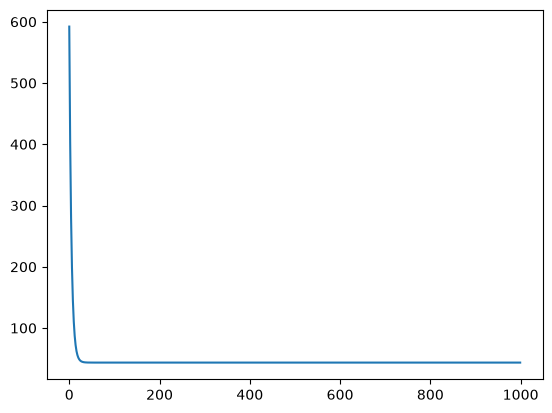

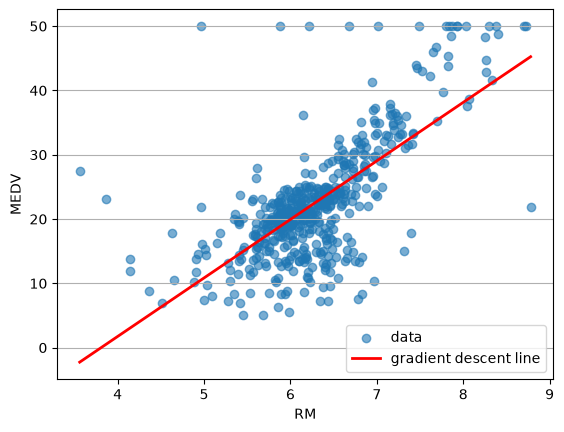

In [41]:
# TODO: loss_history를 선 그래프로 그리세요.
plt.figure()

plt.plot(loss_history)

plt.show()
# TODO: 원본 RM 범위로 x_line_raw를 만들고 scaler로 변환하세요.
x_line_raw = np.linspace(X_raw.min(), X_raw.max(), 100).reshape(-1, 1)
x_line_scaled = scaler.transform(x_line_raw)

# TODO: 학습된 w0, w1로 회귀선 y값을 예측하고 산점도 위에 그리세요.

y_line = predict_linear(x_line_scaled, w0, w1)

plt.scatter(X_raw, y, alpha=0.6, label='data')
plt.plot(x_line_raw, y_line, color='red', linewidth=2, label='gradient descent line')

plt.xlabel('RM')
plt.ylabel('MEDV')
plt.legend()
plt.grid(axis='y')
plt.show()
